## This notebook will describe the analysis for 
# Our comparitive analysis of the different population estimation approaches 

Rose Foster-Dyer   
Updated 02.09.2026
___ 

### Data types available (2024, 2025)
- SAR-derived breeding pairs (one count per year from midwinter) 
- SAR-derived individuals (one count per month through winter)
- VHR-derived abundance index using bayesian model (one per year from spring)
- VHR-derived abundance index using windchill model (one per year from spring)
- chick counts (available for four sites)
- adult counts (available from just one site (Crozier))

I first plan to create a figure for each site, one panel per year (2024 and 2025) with all data sources included 

I also want to create a simple table showing the data available per type per year. 


I will also perform some simple statistical analyses to compare the results produced through each method. 

___

This paper will be prepared for Conservation Letters or something similar, and will be presented as a caution of the conclusions that can be drawn from a singular population estimation approach. 

___ 

This will use methods described in:   
- Foster-Dyer et al. "Midwinter radar imaging establishes first breeding population baseline for the endangered emperor penguin" submitted to Science Advances. 
- LaRue et al. 2024 "Advances in remote sensing..." Proc B. 
- Foster-Dyer et al. 2026 "Evidence of emperor penguins sensitivity to sea ice fluctuations" Proc B. 
- Winterl et al. 2024 "Remote sensing and emperor penguins..." Nature Comms. 

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

In [69]:
# Loading data 

INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/Github/SAR_RossSea_compare/SAR_RossSea_compare/"

df_RossSea = pd.read_csv(os.path.join(INPUTPATH, "Data/RS_pops2425_combined.csv"))


In [70]:
df_RossSea.info()
df_RossSea.head()



<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   colony    157 non-null    str    
 1   site_id   157 non-null    str    
 2   type      157 non-null    str    
 3   date      154 non-null    str    
 4   month     154 non-null    float64
 5   day       154 non-null    float64
 6   year      157 non-null    int64  
 7   DOY       154 non-null    float64
 8   lat       157 non-null    float64
 9   lon       157 non-null    float64
 10  count     150 non-null    float64
 11  count_se  140 non-null    float64
 12  method    157 non-null    str    
 13  notes     26 non-null     str    
dtypes: float64(7), int64(1), str(6)
memory usage: 23.5 KB


,colony,site_id,type,date,month,day,year,DOY,lat,lon,count,count_se,method,notes
0,Crozier,CROZ,adults,21/11/2024,11.0,21.0,2024,325.0,-77.452742,169.275066,1075.0,NaN,adults,"Annie Schmidt, Grant Ballard"
1,Crozier,CROZ,adults,22/11/2025,11.0,22.0,2025,326.0,-77.452742,169.275066,627.0,NaN,adults,"Annie Schmidt, Grant Ballard"
2,Coulman,COUL,chicks,21/11/2024,11.0,21.0,2024,325.0,-73.350000,169.610000,21242.0,NaN,chicks,Jeong-Hoon Kim
3,Coulman,COUL,chicks,6/12/2025,12.0,6.0,2025,340.0,-73.350000,169.610000,6686.0,NaN,chicks,Jeong-Hoon Kim
4,Crozier,CROZ,chicks,21/11/2024,11.0,21.0,2024,325.0,-77.452742,169.275066,2773.0,NaN,chicks,"Annie Schmidt, Grant Ballard"


In [71]:
df_RossSea.columns

Index(['colony', 'site_id', 'type', 'date', 'month', 'day', 'year', 'DOY',
       'lat', 'lon', 'count', 'count_se', 'method', 'notes'],
      dtype='str')

In [72]:
df_RossSea[df_RossSea['year'].isna()]

,colony,site_id,type,date,month,day,year,DOY,lat,lon,count,count_se,method,notes


In [73]:
# Convert the 'year' column to integers
df_RossSea['year'] = df_RossSea['year'].astype(int)


In [76]:
# This will work perfectly now!
df_RossSea = df_RossSea.astype({
    'method': 'category',
    'type': 'category',
    'colony': 'category',
    'year': 'category'
})

In [77]:
# Loop through your categorical columns
for col in ['colony', 'type', 'method', 'year']:
    print(f"\nLevels in '{col}':")
    print(list(df_RossSea[col].cat.categories))


Levels in 'colony':
['Beaufort', 'Colbeck', 'Coulman', 'Crozier', 'Franklin', 'Roget', 'Washington']

Levels in 'type':
['abundance index', 'adults', 'breeding pairs', 'chicks', 'individuals']

Levels in 'method':
['SAR', 'SAR-bp', 'VHR-bayes', 'VHR-rho', 'adults', 'chicks']

Levels in 'year':
[2024, 2025]


# Creating a figure that shows the year long cycle of population change for Ross Sea colonies 

(these ideas were written back in April)

Also incorporate chick counts, a line to identify the point at which the iceberg arrived at Coulman 

And possibly change shapes of points depending on estimate phenological stage 


- Arrival/Courtship  
- Mating 
- Female departure 
- Peak male huddle  
- Female return  

Should we also include the 2024 data from the Ross Sea? 
- Crozier 
- Washington? Roget? 
- Coulman 

## Simple exploratory plot 

I want to first create a simple exploratory plot for each site, for each method, maybe one panel per method, with different colours for each year? 



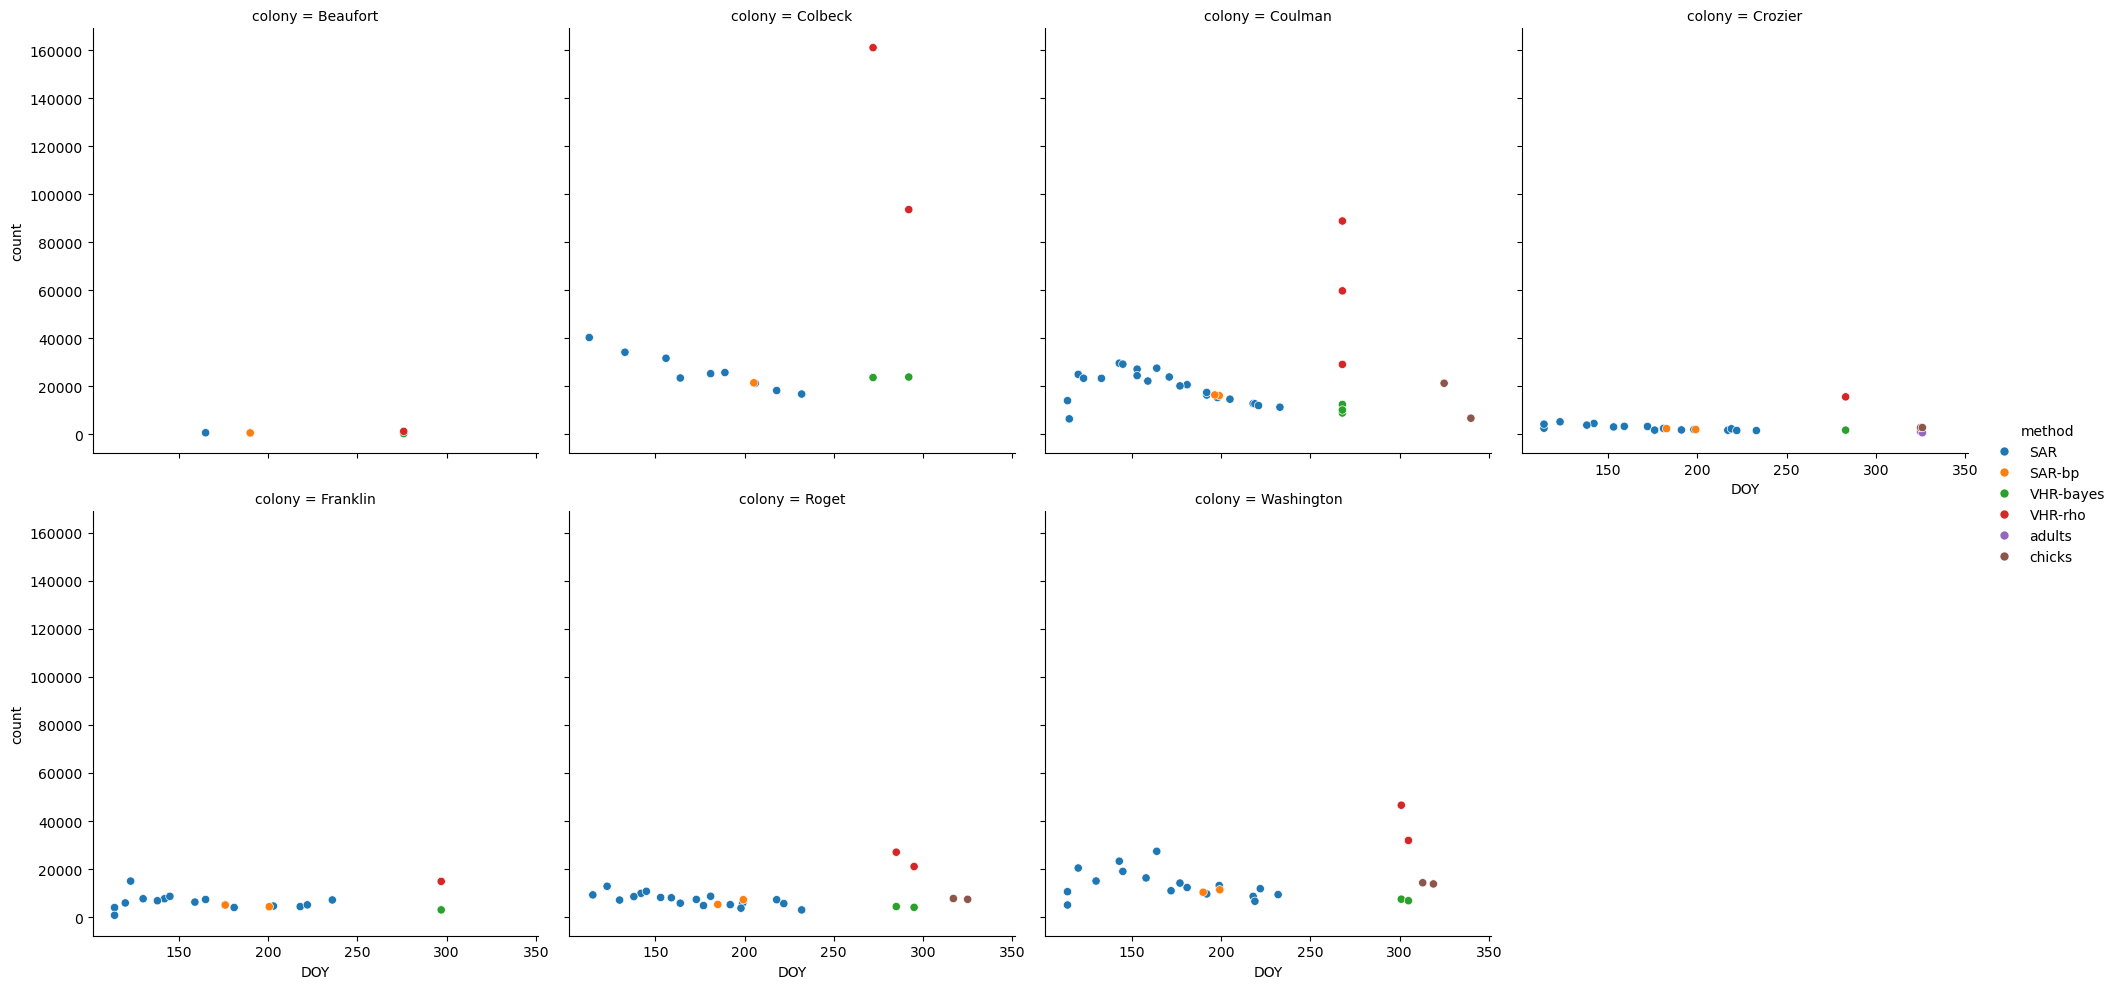

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creates a row of separate subplots for each colony
sns.relplot(
    data=df_RossSea, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4)

plt.show()

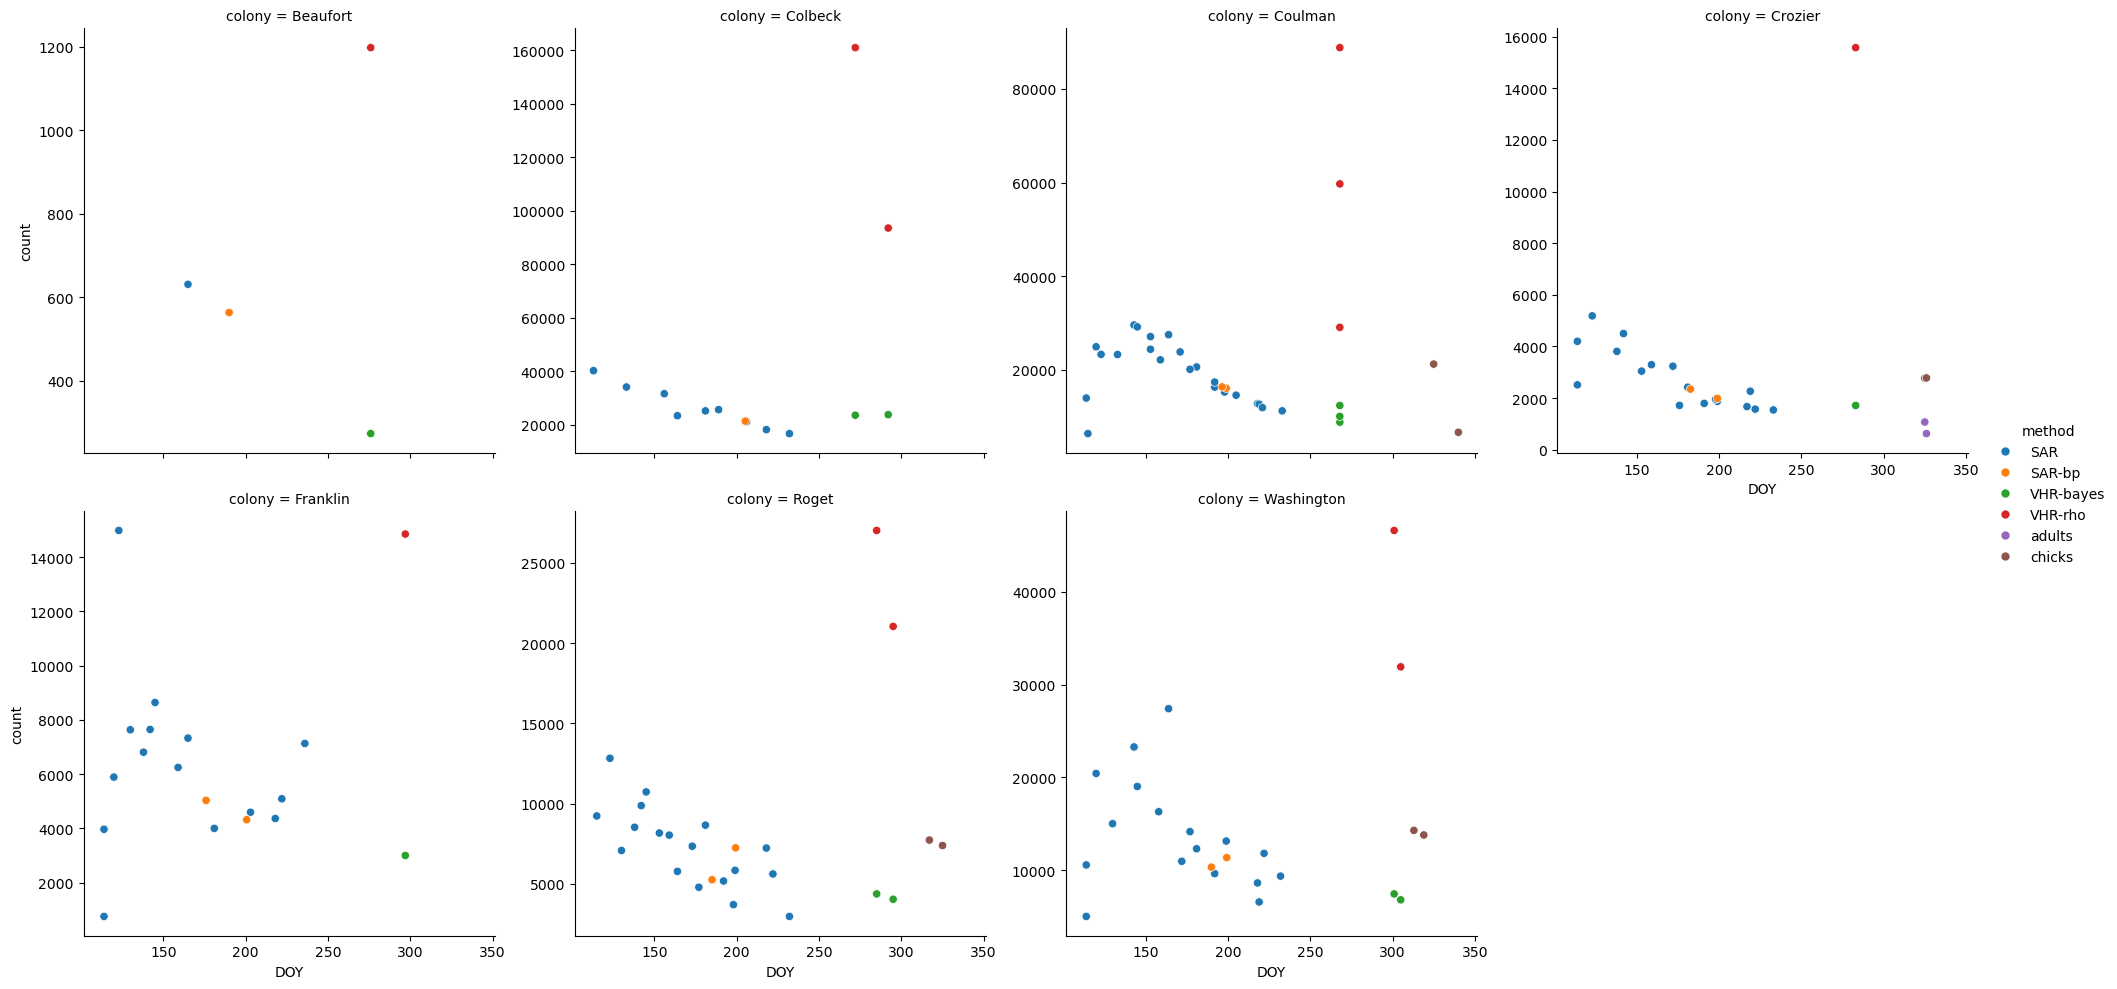

In [79]:
# Recreating above plot with unique yaxes so we can better see the data range 

# Creates a row of separate subplots for each colony
sns.relplot(
    data=df_RossSea, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4, 
    facet_kws=dict(sharey=False))

plt.show()

## We want to exlcude the VHR-rho data 

These data are those that used the huddle areas derived from high resolution optical imagery along with the Winterl et al. 2024 windchill model and they produce non sensical data.   

This is becuase the rho values vary between 4.275 and 6.059 birds per m2, which when individual penguins are included on the ice, not huddled, creates a vast overestimation about how many birds there are in each meter. 



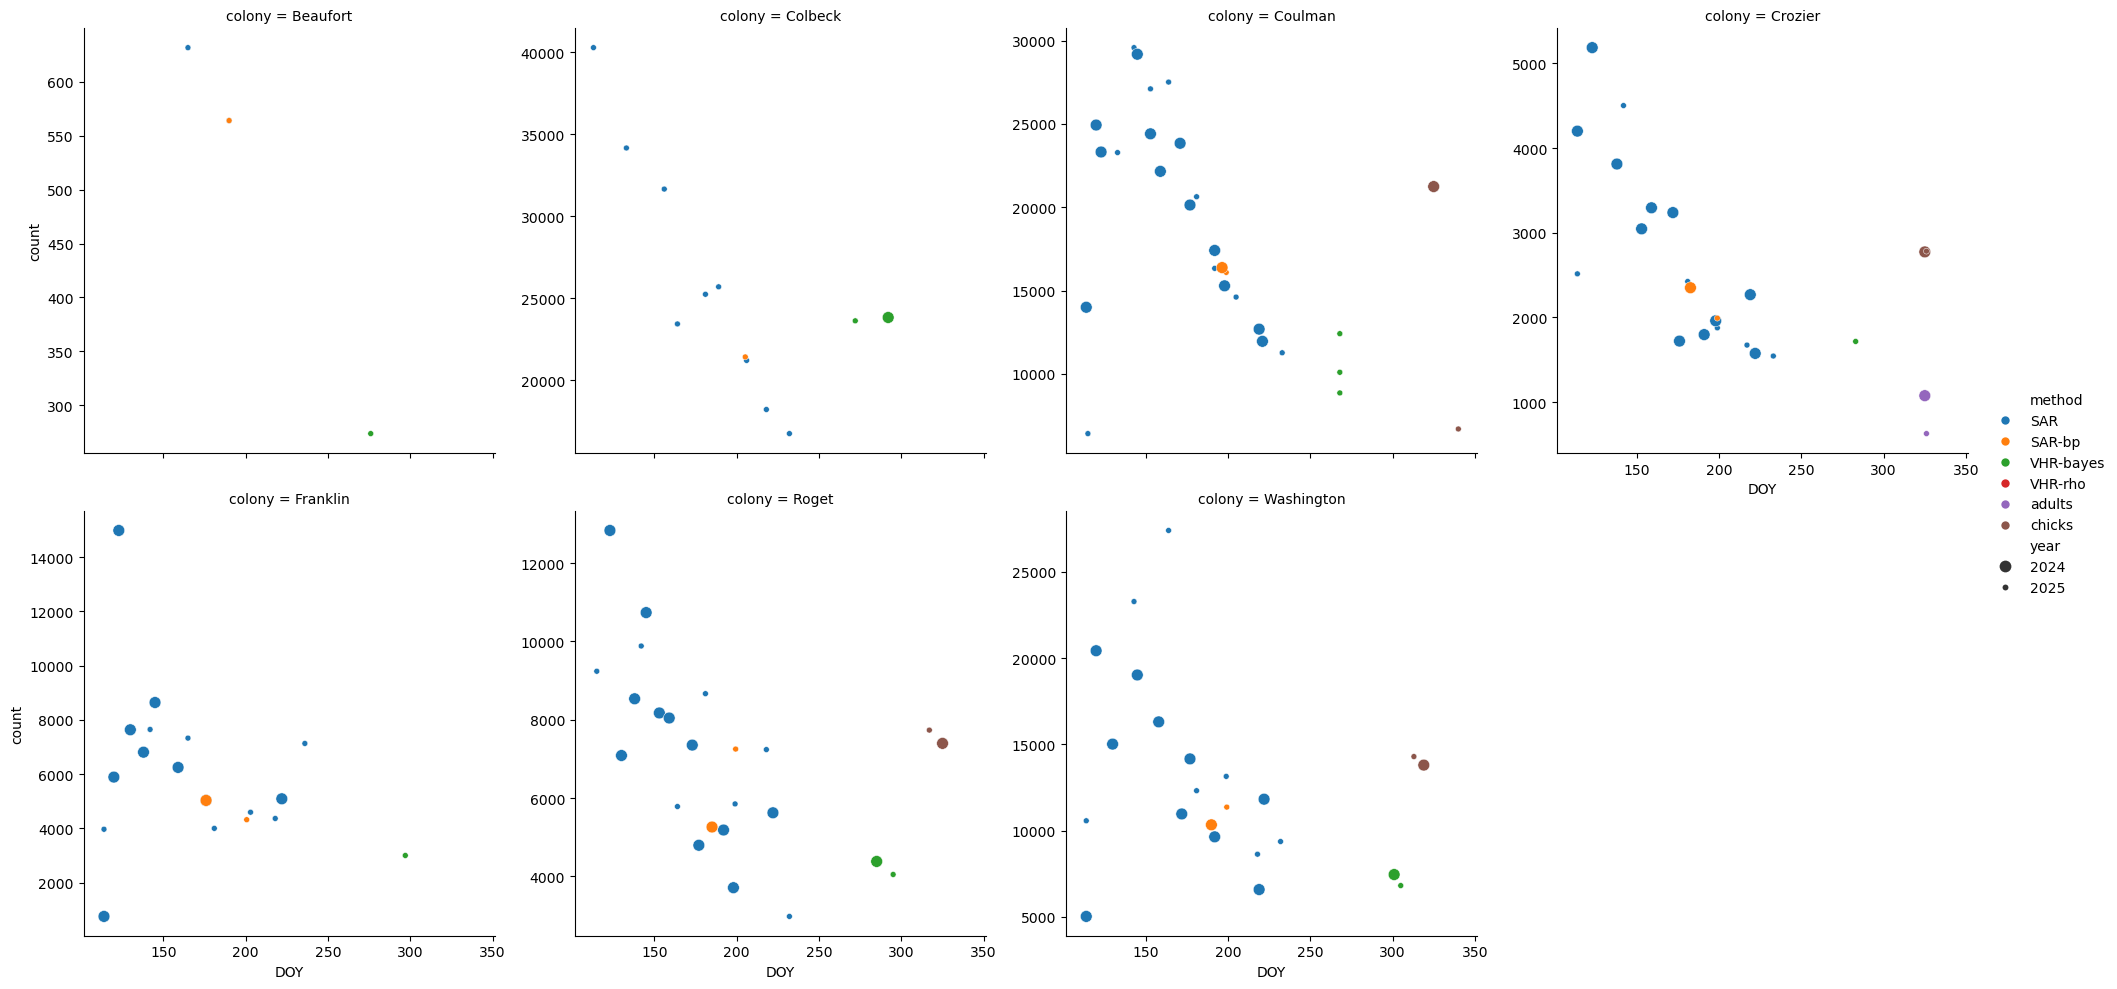

In [80]:
# Exclude a level from method 

filtered_df_RS = df_RossSea[df_RossSea["method"] != "VHR-rho"]

# Creates a row of separate subplots for each colony
sns.relplot(
    data=filtered_df_RS, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4, 
    size = 'year', 
    facet_kws=dict(sharey=False))

plt.show()

In [ ]:

# ── One figure per colony ─────────────────────────────────────────────────────
output_folder = os.path.join(INPUTPATH, "Results/colony_plots")
os.makedirs(output_folder, exist_ok=True)
colonies_all = sorted(df_RossSea["colony"].unique())

for colony in colonies_all:
    df = df_RossSea[df_RossSea["colony"] == colony].copy()
    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time")

    if len(df) == 0:
        continue

    color = "#0072B2"

    fig, axes = plt.subplots(1, 1, figsize=(6, 9), sharex=True)



    # ── Panel  Count ─────────────────────────────────────────────────────────
    df_c = df[df["count"].notna() & (df["count"] != 0)]
    if len(df_c) > 0:
        ax.plot(df_c["date_time"], df_c["count"],
                color=color, linewidth=1.8, alpha=1)
        ax.scatter(df_c["date"], df_c["count"],
                   s=30, color=color, zorder=3)
        if "count_lower" in df_c.columns and "count_upper" in df_c.columns:
            err_low  = np.maximum(df_c["count"] - df_c["count_se"], 0)
            err_high = np.maximum(df_c["count_se"] + df_c["count_pred"], 0)
            ax.fill_between(df_c["date"],
                            df_c["count"] - err_low,
                            df_c["count"] + err_high,
                            color=color, alpha=0.2)

    # ── Formatting ─────────────────────────────────────────────────────────────
    axes.set_ylabel("Predicted Count\n(individuals)", fontsize=9)



    # Month labels on x axis
    axes.xaxis.set_major_locator(mdates.MonthLocator())
    axes.xaxis.set_major_formatter(mtick.NullFormatter())
    axes.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
    axes.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
    for label in axes[2].xaxis.get_minorticklabels():
        label.set_rotation(30)
        label.set_ha("right")
        label.set_fontsize(9)
    axes.tick_params(axis="x", which="minor", length=0)

    fig.suptitle(colony, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)

    # Save — colony name for filename
    safe_name = colony.replace(" ", "_").replace("/", "-")
    filepath = os.path.join(output_folder, f"{safe_name}_phenology.png")
    plt.savefig(filepath, bbox_inches="tight", dpi=150)
    plt.close()
    print(f"Saved: {safe_name}_timeseries.png")

print(f"\nDone — {len(colonies_all)} figures saved to: {output_folder}")

TypeError: '<' not supported between instances of 'float' and 'str'